In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# import lib_plot


from lib_equations import root_finder, herm_coeff, herm_func, trapezoidal, Simpson, Gauss_Leg


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


H_6(x) =  -120 + 720x^2 - 480x^4 + 64x^6


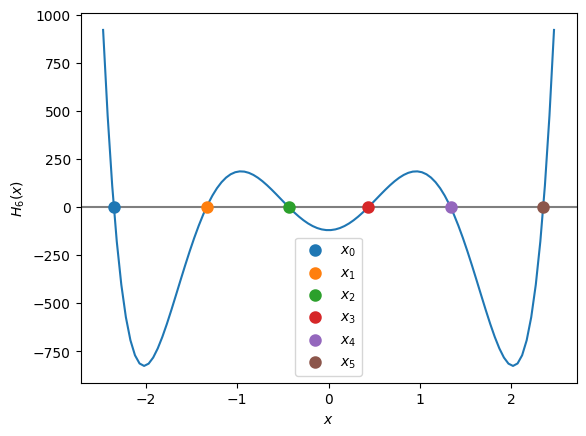

In [16]:
deg = 6
H_coeff = np.flip(herm_coeff(deg))
H_roots = root_finder(herm_coeff(deg))

coeffs = H_coeff
terms = []
for i, c in enumerate(coeffs):
    if np.isclose(c, 0):
        continue
    coeff = int(c) if np.isclose(c, round(c)) else float(c)
    sign = "+" if c > 0 else "-"
    abs_coeff = abs(coeff)
    if i == 0:
        term = f"{abs_coeff}"
    elif i == 1:
        term = f"{abs_coeff}x"
    else:
        term = f"{abs_coeff}x^{i}"
    if terms:
        terms.append(f" {sign} {term}")
    else:
        terms.append(f"{'-' if c < 0 else ''}{term}")
poly_str = "".join(terms) if terms else "0"
print(f'H_{deg}(x) = ', poly_str)

limx = max(H_roots)*1.05
xcoo = np.linspace(-limx, limx, 100, dtype=float)
ycoo = herm_func(xcoo, deg)

plt.plot(xcoo, ycoo)
for i, root in enumerate(H_roots):
    plt.scatter(root, 0, marker='o', zorder=3, lw=3, label=rf'$x_{i}$')

plt.axhline(color='black', alpha=0.5)
plt.ylim()

plt.xlabel(rf'$x$')
plt.ylabel(rf'$H_{deg}(x)$')
plt.legend()
plt.show()



In [17]:

from lib_equations import H_weigts, Gauss_Herm

func = lambda x: 1 / (1+x**2)

deg = 15
xcoo = root_finder(herm_coeff(deg))
ycoo = H_weigts(xcoo, deg)

res = Gauss_Herm(func, deg)
print(f'Result (n={deg}) = ', res)


NameError: name 'H_weigts' is not defined

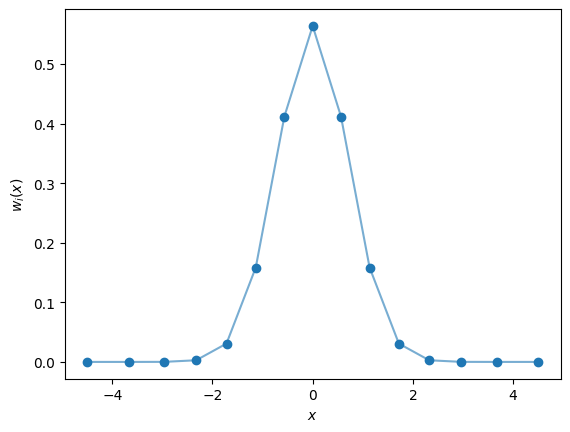

In [ ]:

plt.plot(xcoo, ycoo, alpha=0.6)
plt.scatter(xcoo, ycoo, zorder=3, label='Radici ')
plt.xlabel(r'$x$')
plt.ylabel(rf'$w_i(x)$')
plt.show()


In [ ]:
true = np.e * np.pi * math.erfc(1)

n_deg = np.arange(1, 21)
errs_1 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_1.append(err)


n --> res:
    1  -->   1.7724538509055159
       -->   4.3e-01

    2  -->   1.1816359006036627
       -->   1.6e-01

    3  -->   1.4179630807244181
       -->   7.5e-02

    4  -->   1.306018626983056
       -->   3.7e-02

    5  -->   1.3634260391580975
       -->   2.0e-02

    6  -->   1.331892179921353
       -->   1.1e-02

    7  -->   1.3500262746454836
       -->   6.7e-03

    8  -->   1.3391873540175196
       -->   4.1e-03

    9  -->   1.3458700894018625
       -->   2.6e-03

    10 -->   1.341639261167652
       -->   1.7e-03

    11 -->   1.3443774750608917
       -->   1.1e-03

    12 -->   1.3425705087384046
       -->   7.2e-04

    13 -->   1.3437831843743089
       -->   4.9e-04

    14 -->   1.3424352941223288
       -->   8.6e-04

    15 -->   1.343527415363498
       -->   2.3e-04

    16 -->   1.3431287459796302
       -->   1.6e-04

    17 -->   1.3434104959179414
       -->   1.2e-04



C:\Users\Marco\AppData\Local\Temp\ipykernel_9420\2866075499.py:3: RuntimeWarning: overflow encountered in scalar multiply
  num = 2**(n-1) * factorial(n-1) * np.sqrt(np.pi)


    18 -->   -0.25122353950113235
       -->   1.6e+00

    19 -->   -0.0002480117859460635
       -->   1.3e+00

    20 -->   0.000140526154987582
       -->   1.3e+00



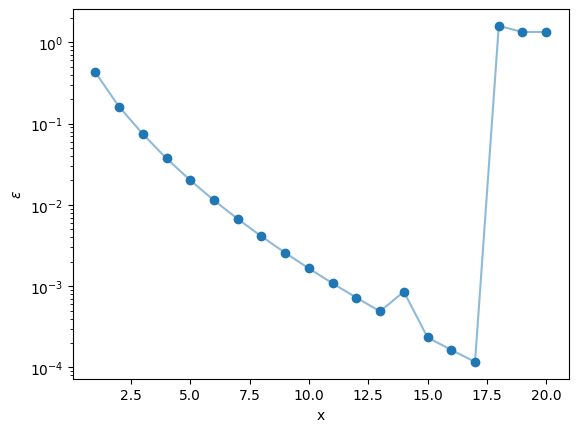

In [ ]:
plt.plot(n_deg, errs_1, alpha=0.5)
plt.scatter(n_deg, errs_1)
plt.xlabel(rf'x')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')
plt.show()


n --> res:
    1  -->   0.0
       -->   5.8e+00

    2  -->   0.055389182840797635
       -->   5.8e+00

    3  -->   1.4955079367015371
       -->   4.3e+00

    4  -->   4.4865238101046785
       -->   1.3e+00

    5  -->   5.81586419828419
       -->   4.7e-13

    6  -->   5.815864198284458
       -->   7.3e-13

    7  -->   5.815539262774879
       -->   3.2e-04

    8  -->   5.815864198284626
       -->   9.0e-13

    9  -->   5.815864198284381
       -->   6.6e-13

    10 -->   5.815864198285417
       -->   1.7e-12

    11 -->   5.815857962973655
       -->   6.2e-06

    12 -->   5.815864198284644
       -->   9.2e-13

    13 -->   5.772544864096987
       -->   4.3e-02

    14 -->   5.815864242964158
       -->   4.5e-08

    15 -->   5.8190967604067705
       -->   3.2e-03

    16 -->   5.816885478622927
       -->   1.0e-03

    17 -->   5.8158671929249435
       -->   3.0e-06



C:\Users\Marco\AppData\Local\Temp\ipykernel_9420\2866075499.py:3: RuntimeWarning: overflow encountered in scalar multiply
  num = 2**(n-1) * factorial(n-1) * np.sqrt(np.pi)


    18 -->   -1.0747376808562268
       -->   6.9e+00

    19 -->   -0.0010744323120413833
       -->   5.8e+00

    20 -->   0.0006084438733736782
       -->   5.8e+00



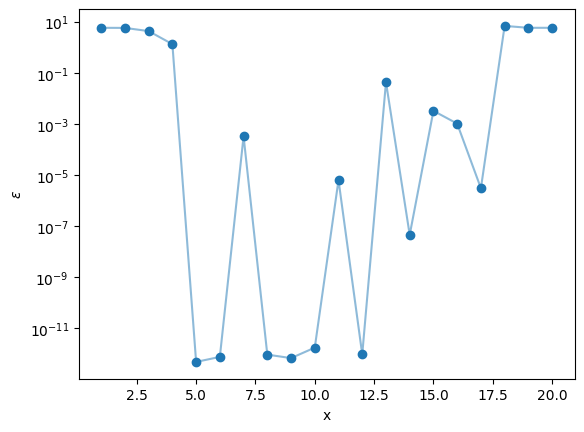

In [ ]:
func = lambda x: 1/2 * x**8
true = 105/32 * np.sqrt(np.pi)

n_deg = np.arange(1, 21)
errs_2 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_2.append(err)

plt.plot(n_deg, errs_2, alpha=0.5)
plt.scatter(n_deg, errs_2)
plt.xlabel(rf'x')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')
plt.show()


n --> res:
    1  -->   0.053153378345782105
       -->   4.7e-02

    2  -->   0.002200617889896386
       -->   4.0e-03

    3  -->   0.03549874033202738
       -->   2.9e-02

    4  -->   0.004643040173549341
       -->   1.6e-03

    5  -->   0.028648700010444863
       -->   2.2e-02

    6  -->   0.0062784809814775714
       -->   4.6e-05

    7  -->   0.024934650324520795
       -->   1.9e-02

    8  -->   0.007385403496000458
       -->   1.2e-03

    9  -->   0.022599812246662434
       -->   1.6e-02

    10 -->   0.00816995378081398
       -->   1.9e-03

    11 -->   0.02099722084357652
       -->   1.5e-02

    12 -->   0.00875049754316961
       -->   2.5e-03

    13 -->   0.01982997212268236
       -->   1.4e-02

    14 -->   0.009195608106955813
       -->   3.0e-03

    15 -->   0.01894230185059961
       -->   1.3e-02

    16 -->   0.009546946804572114
       -->   3.3e-03

    17 -->   0.018244946510940326
       -->   1.2e-02



C:\Users\Marco\AppData\Local\Temp\ipykernel_9420\2866075499.py:3: RuntimeWarning: overflow encountered in scalar multiply
  num = 2**(n-1) * factorial(n-1) * np.sqrt(np.pi)


    18 -->   -0.0018387028713504287
       -->   8.1e-03

    19 -->   -3.264606962225217e-06
       -->   6.2e-03

    20 -->   1.0529605346181874e-06
       -->   6.2e-03



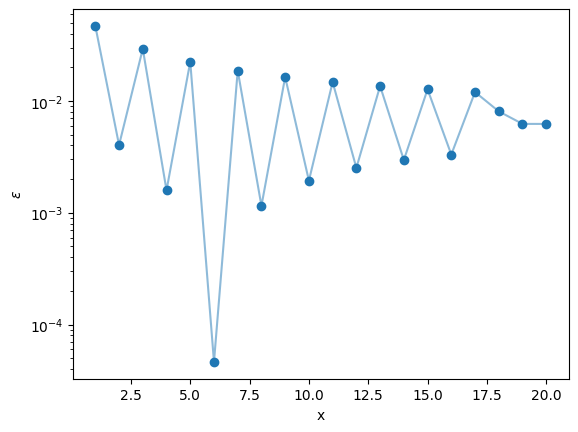

In [ ]:
func = lambda x: (np.abs(x)+3)**5 * np.exp(-6*np.abs(x) - 9)
true = 101*np.exp(-9) / 2 

n_deg = np.arange(1, 21)
errs_3 = []
print('n --> res:')
for deg in n_deg:
    res = Gauss_Herm(func, deg)
    err = abs(res - true)
    if deg<10:
        print(f'    {deg}  -->   {res}')
    else:
        print(f'    {deg} -->   {res}')
    print(f'       -->   {err:.1e}\n')
    errs_3.append(err)

plt.plot(n_deg, errs_3, alpha=0.5)
plt.scatter(n_deg, errs_3)
plt.xlabel(rf'x')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')
plt.show()
